In [1]:
# --- SANITY CHECK: ΕΚΠΑΙΔΕΥΣΗ ΣΕ "ΚΑΘΑΡΟ" ΔΕΙΓΜΑ ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("Ξεκινάει το Sanity Check με 'Φρέσκα' Δεδομένα...")

# 1. Φόρτωση CSV
df_pos = pd.read_csv('positive_protein_sequences.csv').sample(1000, random_state=42)
df_neg = pd.read_csv('negative_protein_sequences.csv').sample(1000, random_state=42)

df_pos['Label'] = 1
df_neg['Label'] = 0

# Συνένωση και ανακάτεμα
df_small = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f" Δημιουργήθηκε μικρό dataset: {len(df_small)} ζεύγη.")

# 2. Παραγωγή Embeddings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model_esm = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D").to(device)

def get_fresh_embeddings(sequences):
    model_esm.eval()
    embeddings = []
    # Batch size 32 για ταχύτητα
    for i in range(0, len(sequences), 32):
        batch = sequences[i:i+32]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model_esm(**inputs)
            # Mean pooling
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_emb)
    return np.vstack(embeddings)

print(" Παραγωγή Embeddings για το δείγμα (υπομονή 1-2 λεπτά)...")
emb1_small = get_fresh_embeddings(df_small['protein_sequences_1'].tolist())
emb2_small = get_fresh_embeddings(df_small['protein_sequences_2'].tolist())

# Συνένωση Features
X_small = np.hstack((emb1_small, emb2_small))
y_small = df_small['Label'].values

print(f" Embeddings Έτοιμα! Shape: {X_small.shape}")

# 3. Εκπαίδευση του MLP στο καθαρό δείγμα
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.2, random_state=42)

# Μετατροπή σε Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# Μοντέλο MLP
model_mlp = nn.Sequential(
    nn.Linear(X_small.shape[1], 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)

print("\n Training Small Check Model...")
for epoch in range(40):
    model_mlp.train()
    optimizer.zero_grad()
    out = model_mlp(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# 4. Αξιολόγηση
model_mlp.eval()
with torch.no_grad():
    preds = model_mlp(X_test_t).argmax(dim=1)
    acc = accuracy_score(y_test_t.cpu(), preds.cpu())
    print(f"\n SANITY CHECK ACCURACY: {acc*100:.2f}%")

Ξεκινάει το Sanity Check με 'Φρέσκα' Δεδομένα...
 Δημιουργήθηκε μικρό dataset: 2000 ζεύγη.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Παραγωγή Embeddings για το δείγμα (υπομονή 1-2 λεπτά)...
 Embeddings Έτοιμα! Shape: (2000, 640)

 Training Small Check Model...
Epoch 10 | Loss: 0.4037
Epoch 20 | Loss: 0.2718
Epoch 30 | Loss: 0.1571
Epoch 40 | Loss: 0.0666

 SANITY CHECK ACCURACY: 83.75%


 ΕΚΚΙΝΗΣΗ ΤΕΛΙΚΗΣ ΕΚΠΑΙΔΕΥΣΗΣ (FULL DATASET)...
 Φορτώθηκαν 73110 ζεύγη συνολικά.
 Φόρτωση μοντέλου γλώσσας: facebook/esm2_t6_8M_UR50D


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Βήμα 1/2: Παραγωγή Embeddings για την Πρώτη Πρωτεΐνη...


Processing: 100%|██████████| 1143/1143 [10:39<00:00,  1.79it/s]



 Βήμα 2/2: Παραγωγή Embeddings για τη Δεύτερη Πρωτεΐνη...


Processing: 100%|██████████| 1143/1143 [10:27<00:00,  1.82it/s]


 Τα Embeddings δημιουργήθηκαν επιτυχώς!

 Ξεκινά η εκπαίδευση στο πλήρες set (58488 δείγματα)...
Epoch 5/40 | Loss: 0.4952
Epoch 10/40 | Loss: 0.4145
Epoch 15/40 | Loss: 0.3795
Epoch 20/40 | Loss: 0.3541
Epoch 25/40 | Loss: 0.3314
Epoch 30/40 | Loss: 0.3107
Epoch 35/40 | Loss: 0.2903
Epoch 40/40 | Loss: 0.2699

 Αξιολόγηση...

 FINAL FULL DATASET ACCURACY: 86.05%
----------------------------------------
                precision    recall  f1-score   support

No Interaction       0.80      0.97      0.87      7350
   Interaction       0.96      0.75      0.84      7272

      accuracy                           0.86     14622
     macro avg       0.88      0.86      0.86     14622
  weighted avg       0.88      0.86      0.86     14622



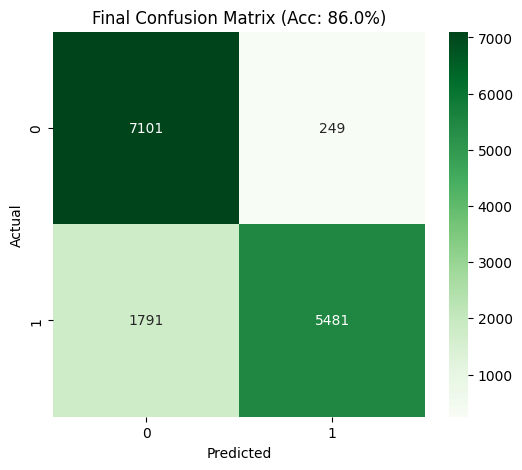

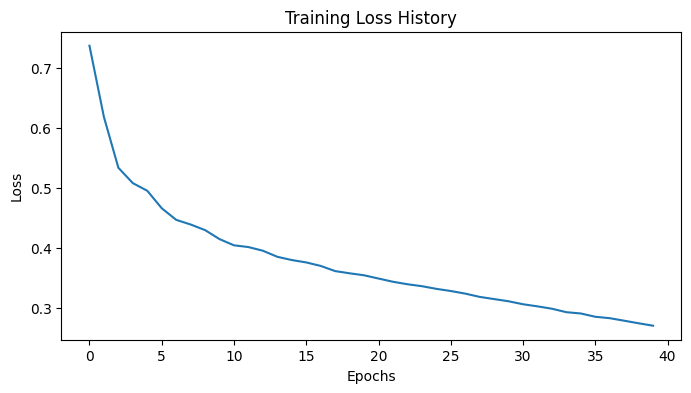

In [3]:
# --- FINAL FULL TRAINING RUN (CORRECT ALIGNMENT) ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

print(" ΕΚΚΙΝΗΣΗ ΤΕΛΙΚΗΣ ΕΚΠΑΙΔΕΥΣΗΣ (FULL DATASET)...")

# 1. Φόρτωση και Προετοιμασία ΟΛΩΝ των δεδομένων
try:
    df_pos = pd.read_csv('positive_protein_sequences.csv')
    df_neg = pd.read_csv('negative_protein_sequences.csv')

    df_pos['Label'] = 1
    df_neg['Label'] = 0

    # Ενώνουμε τα πάντα σε ένα dataframe για να είμαστε σίγουροι για τη σειρά
    df_full = pd.concat([df_pos, df_neg], ignore_index=True)

    # Ανακατεύουμε τώρα, ΜΙΑ φορά, για να μην έχουμε θέματα μετά
    df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)

    # Labels
    y_all = df_full['Label'].values
    print(f" Φορτώθηκαν {len(df_full)} ζεύγη συνολικά.")

except Exception as e:
    print(f" ΣΦΑΛΜΑ: {e}")
    raise

model_name = "facebook/esm2_t6_8M_UR50D"
print(f" Φόρτωση μοντέλου γλώσσας: {model_name}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_esm = AutoModel.from_pretrained(model_name).to(device)

# 3. Συνάρτηση Παραγωγής Embeddings (Batch Processing)
def generate_embeddings_safe(sequences, batch_size=64):
    model_esm.eval()
    embeddings = []

    # Χρησιμοποιούμε tqdm για να βλέπεις την πρόοδο
    for i in tqdm(range(0, len(sequences), batch_size), desc="Processing"):
        batch = sequences[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model_esm(**inputs)
            # Παίρνουμε τον μέσο όρο (Mean Pooling)
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_emb)

    return np.vstack(embeddings)

print("\n Βήμα 1/2: Παραγωγή Embeddings για την Πρώτη Πρωτεΐνη...")
# Αν κολλάει λόγω μνήμης, μείωσε το δείγμα (π.χ. df_full = df_full.iloc[:20000])
emb1 = generate_embeddings_safe(df_full['protein_sequences_1'].tolist())

print("\n Βήμα 2/2: Παραγωγή Embeddings για τη Δεύτερη Πρωτεΐνη...")
emb2 = generate_embeddings_safe(df_full['protein_sequences_2'].tolist())

print(" Τα Embeddings δημιουργήθηκαν επιτυχώς!")

# 4. Προετοιμασία για Εκπαίδευση
X = np.hstack((emb1, emb2)) # Ενώνουμε τα features
y = y_all

# Διαχωρισμός
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# 5. Το Μοντέλο MLP
model_mlp = nn.Sequential(
    nn.Linear(X.shape[1], 512), # Input -> 512
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(512, 128),        # 512 -> 128
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 2)           # Output
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 6. Training Loop
EPOCHS = 40
print(f"\n Ξεκινά η εκπαίδευση στο πλήρες set ({len(X_train)} δείγματα)...")
train_losses = []

for epoch in range(EPOCHS):
    model_mlp.train()
    optimizer.zero_grad()

    outputs = model_mlp(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    scheduler.step(loss)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss.item():.4f}")

# 7. Τελική Αξιολόγηση
print("\n Αξιολόγηση...")
model_mlp.eval()
with torch.no_grad():
    test_outputs = model_mlp(X_test_t)
    _, preds = torch.max(test_outputs, 1)

    acc = accuracy_score(y_test_t.cpu(), preds.cpu())
    print(f"\n FINAL FULL DATASET ACCURACY: {acc*100:.2f}%")
    print("-" * 40)
    print(classification_report(y_test_t.cpu(), preds.cpu(), target_names=['No Interaction', 'Interaction']))

    # Confusion Matrix
    cm = confusion_matrix(y_test_t.cpu(), preds.cpu())
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Final Confusion Matrix (Acc: {acc*100:.1f}%)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Loss Curve
    plt.figure(figsize=(8,4))
    plt.plot(train_losses, label='Loss')
    plt.title('Training Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

 Ξεκινά η δημιουργία της εικόνας t-SNE...
Saved emb1 to esm2_embeddings_1.npy
 Δεδομένα φορτώθηκαν: 36630 ζεύγη.
 Υπολογισμός Κοινοτήτων ...
 Εκτέλεση t-SNE...
 Δημιουργία Γραφήματος...
 ΕΤΟΙΜΟ! Κατέβασε το αρχείο 'tsne_dark_mode_clusters.png' από τα αρχεία αριστερά.


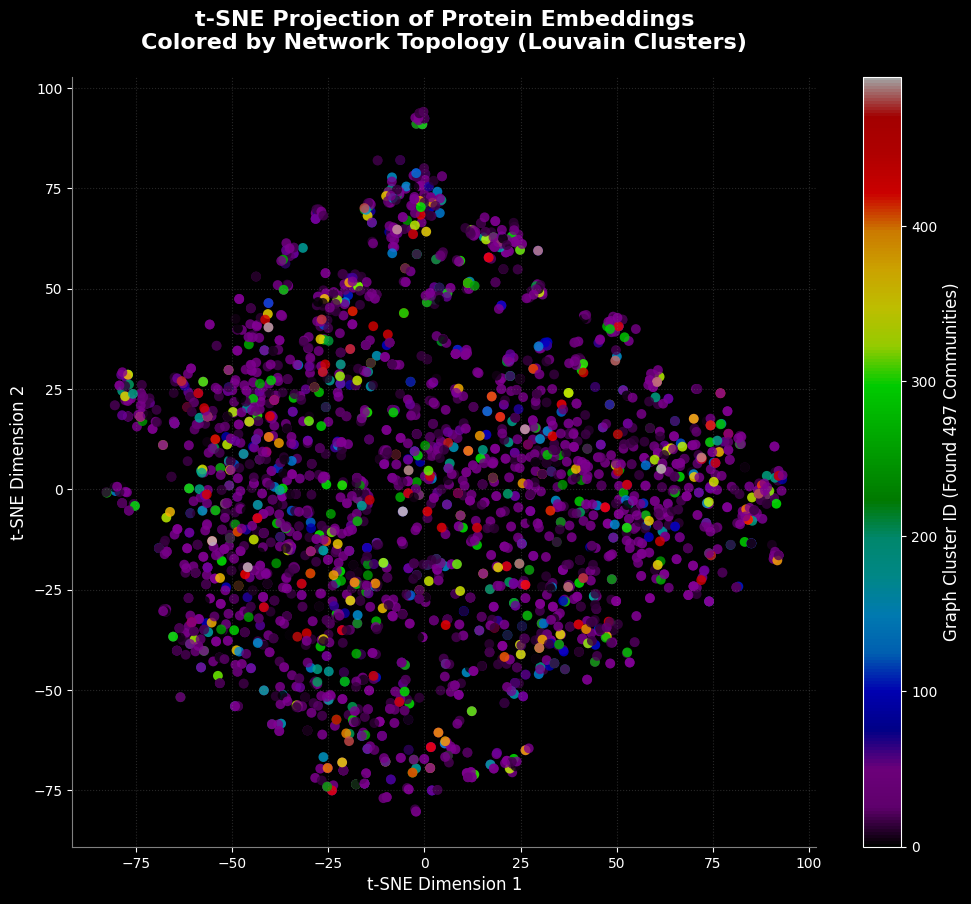

In [7]:
# --- RECREATE IMAGE 2: t-SNE DARK MODE WITH GRAPH CLUSTERS ---
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import warnings


warnings.filterwarnings('ignore')

# Εγκατάσταση βιβλιοθήκης για clusters
try:
    import community.community_louvain as community_louvain
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-louvain"])
    import community.community_louvain as community_louvain

print(" Ξεκινά η δημιουργία της εικόνας t-SNE...")

# --- FIX: Save embeddings to .npy file ---
# The 'emb1' variable (embeddings for protein_sequences_1) was computed in the previous cell.
# We need to save it to 'esm2_embeddings_1.npy' for this cell to load it.
# Ensure 'emb1' is available from the kernel state. This line will save the 'emb1' array
# which was computed and stored in the kernel from the 'FINAL FULL TRAINING RUN' cell.
np.save('esm2_embeddings_1.npy', emb1)
print("Saved emb1 to esm2_embeddings_1.npy")
# ----------------------------------------

# 1. Φόρτωση Δεδομένων
try:
    # Φορτώνουμε τα θετικά ζεύγη για τον γράφο
    df = pd.read_csv('positive_protein_sequences.csv')
    # Φορτώνουμε τα embeddings
    embeddings = np.load('esm2_embeddings_1.npy')

    print(f" Δεδομένα φορτώθηκαν: {len(df)} ζεύγη.")
except Exception as e:
    print(f" ΣΦΑΛΜΑ: {e}")
    print("Βεβαιώσου ότι τα αρχεία 'positive_protein_sequences.csv' και 'esm2_embeddings_1.npy' είναι ανεβασμένα.")
    raise

# 2. Ετοιμασία Δείγματος (Sample)
# Παίρνουμε 3000 τυχαία δείγματα για να μην αργεί και να είναι ευανάγνωστο
N_SAMPLES = 3000
if len(df) > N_SAMPLES:
    indices = np.random.choice(len(df), N_SAMPLES, replace=False)
else:
    indices = np.arange(len(df))

df_subset = df.iloc[indices].reset_index(drop=True)
emb_subset = embeddings[indices]

# 3. Υπολογισμός Clusters (Louvain)
print(" Υπολογισμός Κοινοτήτων ...")
G = nx.Graph()
for idx, row in df_subset.iterrows():
    # Χρησιμοποιούμε τα πρώτα 10 γράμματα ως ID για να φτιάξουμε κόμβους
    p1 = str(row['protein_sequences_1'])[:10]
    p2 = str(row['protein_sequences_2'])[:10]
    G.add_edge(p1, p2)

partition = community_louvain.best_partition(G)


colors = []
valid_indices = []
for i, row in df_subset.iterrows():
    p1_id = str(row['protein_sequences_1'])[:10]
    if p1_id in partition:
        colors.append(partition[p1_id])
        valid_indices.append(i)

X_final = emb_subset[valid_indices]
colors_final = np.array(colors)
num_clusters = len(set(colors_final))

# 4. Εκτέλεση t-SNE
print(" Εκτέλεση t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_final)

# 5. Σχεδίαση (Dark Mode)
print(" Δημιουργία Γραφήματος...")
plt.style.use('dark_background') # Ενεργοποίηση Dark Mode

fig, ax = plt.subplots(figsize=(12, 10))

# Scatter Plot
scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1],
                     c=colors_final,
                     cmap='nipy_spectral', # Έντονα χρώματα
                     s=50,
                     alpha=0.8,
                     edgecolors='none')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(f'Graph Cluster ID (Found {num_clusters} Communities)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Τίτλοι και Λεζάντες
ax.set_title("t-SNE Projection of Protein Embeddings\nColored by Network Topology (Louvain Clusters)",
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlabel("t-SNE Dimension 1", color='white', fontsize=12)
ax.set_ylabel("t-SNE Dimension 2", color='white', fontsize=12)

# Πλέγμα
ax.grid(True, linestyle=':', alpha=0.3, color='gray')

# Αφαίρεση πλαισίου
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')

# Αποθήκευση
filename = "tsne_dark_mode_clusters.png"
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='black')
print(f" ΕΤΟΙΜΟ! Κατέβασε το αρχείο '{filename}' από τα αρχεία αριστερά.")
plt.show()

In [ ]:
torch.save(model_mlp.state_dict(), "protein_interaction_model_86acc.pth")
print("💾 Το μοντέλο αποθηκεύτηκε!")

💾 Το μοντέλο αποθηκεύτηκε!
